# Task 1: Term Deposit Subscription Prediction (Bank Marketing)
**DevelopersHub Corporation – Advanced Data Science Internship**

## Objective
Predict whether a bank customer will subscribe to a term deposit as a result of a marketing campaign.

## Dataset
Bank Marketing Dataset – UCI Machine Learning Repository

## Skills Covered
- Classification Modeling
- Feature Encoding
- Model Interpretability (Explainable AI – SHAP)
- Customer Behavior Analysis

In [1]:
# Install required libraries
!pip install shap --quiet

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries loaded successfully!')

Libraries loaded successfully!


In [3]:
from google.colab import files
uploaded = files.upload()   # Upload bank-full.csv here
df = pd.read_csv('bank-additional-full.csv', sep=';')
print(f'Dataset shape: {df.shape}')
df.head()

Saving bank-additional-full.csv to bank-additional-full.csv
Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Dataset Overview

In [4]:
print('Shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
print('\nData Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nStatistical Summary:')
df.describe()

Shape: (41188, 21)

Column names: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Data Types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Missing Values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan       

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
# Target variable distribution
print('Target Variable (y) Distribution:')
print(df['y'].value_counts())
print(f'\nSubscription Rate: {(df["y"]=="yes").mean()*100:.2f}%')

Target Variable (y) Distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Subscription Rate: 11.27%


## 3. Exploratory Data Analysis (EDA)

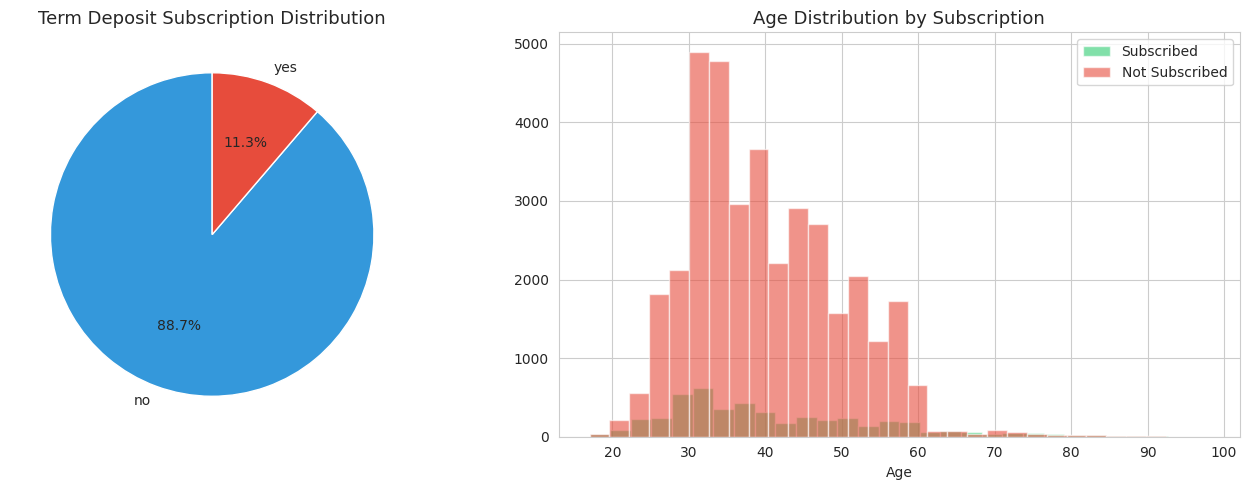

In [6]:
# Target distribution pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['y'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0],
                             colors=['#3498db','#e74c3c'], startangle=90)
axes[0].set_title('Term Deposit Subscription Distribution', fontsize=13)
axes[0].set_ylabel('')

# Age distribution by subscription
df[df['y']=='yes']['age'].hist(bins=30, alpha=0.6, label='Subscribed', color='#2ecc71', ax=axes[1])
df[df['y']=='no']['age'].hist(bins=30, alpha=0.6, label='Not Subscribed', color='#e74c3c', ax=axes[1])
axes[1].set_title('Age Distribution by Subscription', fontsize=13)
axes[1].set_xlabel('Age')
axes[1].legend()
plt.tight_layout()
plt.show()

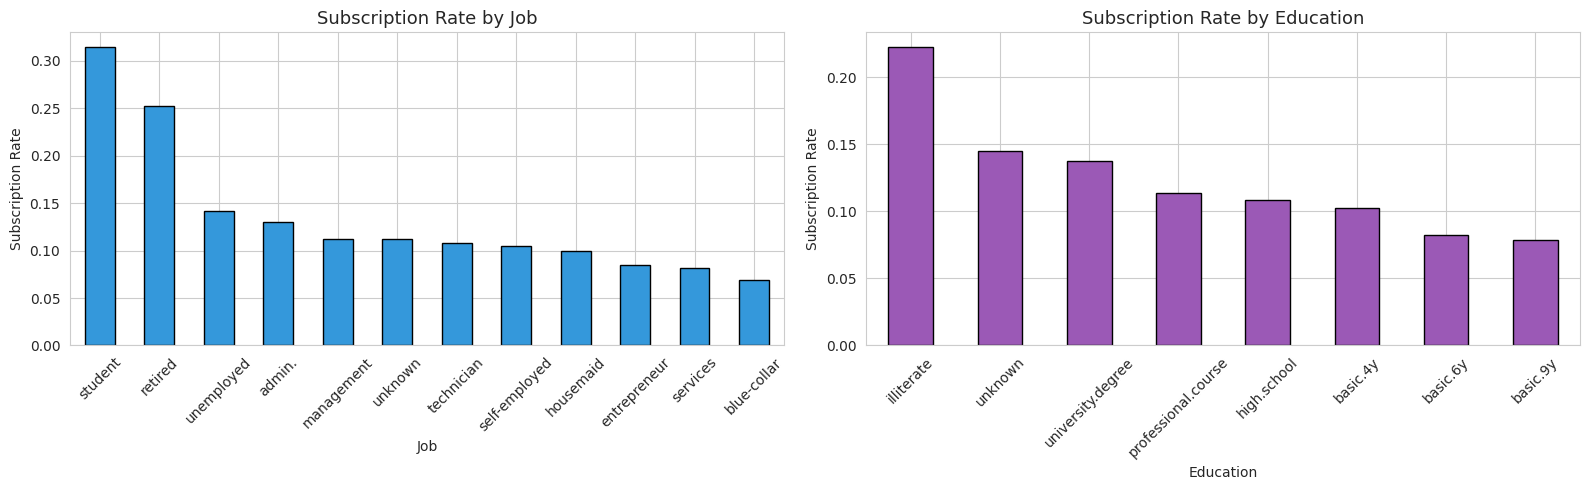

In [7]:
# Job and Education subscription rates
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

job_rate = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean()).sort_values(ascending=False)
job_rate.plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title('Subscription Rate by Job', fontsize=13)
axes[0].set_xlabel('Job')
axes[0].set_ylabel('Subscription Rate')
axes[0].tick_params(axis='x', rotation=45)

edu_rate = df.groupby('education')['y'].apply(lambda x: (x=='yes').mean()).sort_values(ascending=False)
edu_rate.plot(kind='bar', ax=axes[1], color='#9b59b6', edgecolor='black')
axes[1].set_title('Subscription Rate by Education', fontsize=13)
axes[1].set_xlabel('Education')
axes[1].set_ylabel('Subscription Rate')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

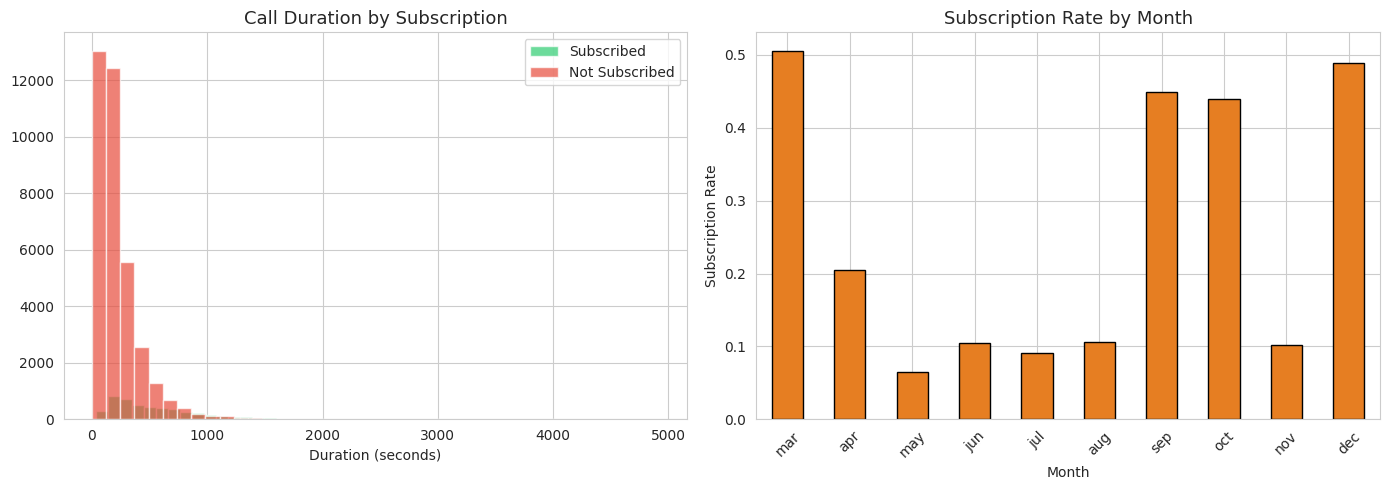

In [8]:
# Contact duration vs subscription
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['y']=='yes']['duration'].hist(bins=40, alpha=0.7, label='Subscribed', color='#2ecc71', ax=axes[0])
df[df['y']=='no']['duration'].hist(bins=40, alpha=0.7, label='Not Subscribed', color='#e74c3c', ax=axes[0])
axes[0].set_title('Call Duration by Subscription', fontsize=13)
axes[0].set_xlabel('Duration (seconds)')
axes[0].legend()

# Month-wise subscription rate
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_rate = df.groupby('month')['y'].apply(lambda x: (x=='yes').mean())
month_rate = month_rate.reindex([m for m in month_order if m in month_rate.index])
month_rate.plot(kind='bar', ax=axes[1], color='#e67e22', edgecolor='black')
axes[1].set_title('Subscription Rate by Month', fontsize=13)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Subscription Rate')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. Feature Encoding & Preprocessing

In [9]:
df_model = df.copy()

# Encode target variable
df_model['y'] = (df_model['y'] == 'yes').astype(int)

# Encode all categorical features using LabelEncoder
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print('Categorical columns to encode:', cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print('\nEncoding complete. Shape:', df_model.shape)
df_model.head()

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Encoding complete. Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


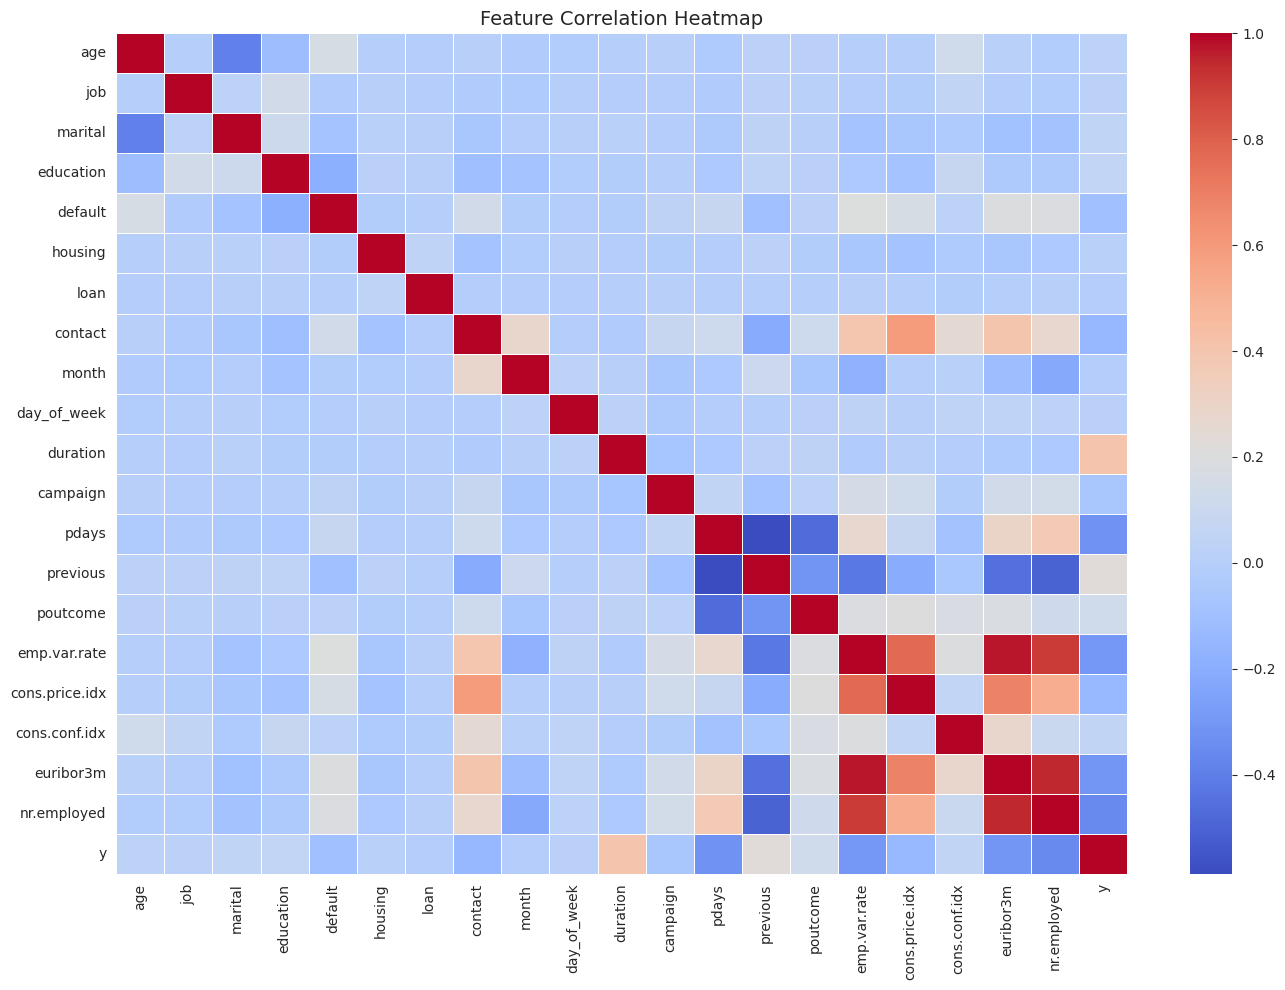

In [11]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
corr = df_model.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# Train-test split
X = df_model.drop('y', axis=1)
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42, stratify=y)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')

Training set: (32950, 20)
Test set:     (8238, 20)


## 5. Model Training & Evaluation

In [13]:
# ── Logistic Regression ───────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression ===')
print(f'Accuracy : {(y_pred_lr == y_test).mean()*100:.2f}%')
print(f'F1-Score : {f1_score(y_test, y_pred_lr):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy : 91.39%
F1-Score : 0.5193
ROC-AUC  : 0.9370

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7310
           1       0.70      0.41      0.52       928

    accuracy                           0.91      8238
   macro avg       0.81      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238



In [14]:
# ── Random Forest ─────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(f'Accuracy : {(y_pred_rf == y_test).mean()*100:.2f}%')
print(f'F1-Score : {f1_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy : 92.04%
F1-Score : 0.6019
ROC-AUC  : 0.9491

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      7310
           1       0.69      0.53      0.60       928

    accuracy                           0.92      8238
   macro avg       0.82      0.75      0.78      8238
weighted avg       0.91      0.92      0.92      8238



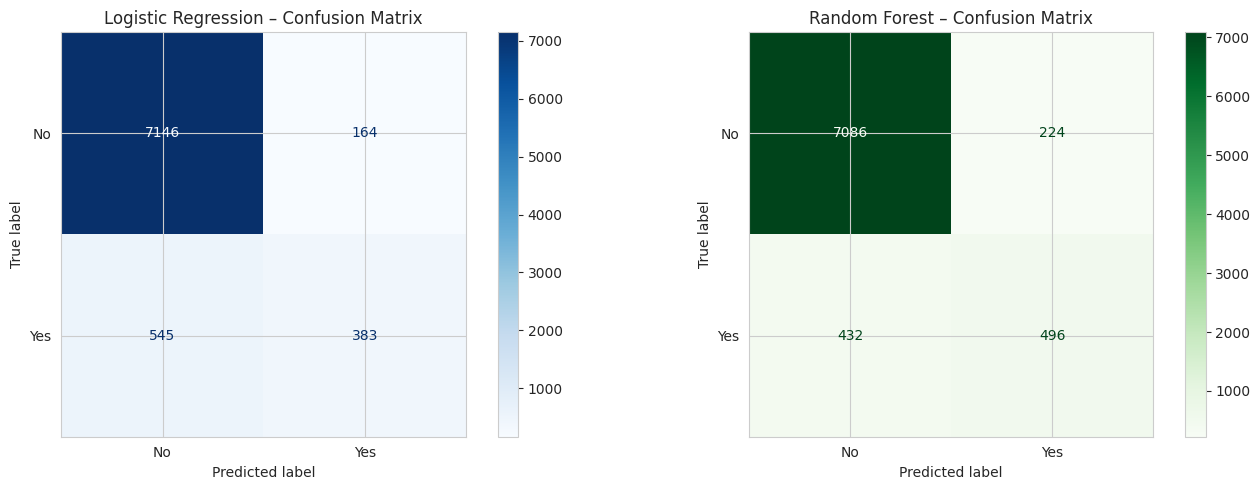

In [16]:
# ── Confusion Matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr),
                       display_labels=['No','Yes']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression – Confusion Matrix', fontsize=12)

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=['No','Yes']).plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest – Confusion Matrix', fontsize=12)
plt.tight_layout()
plt.show()

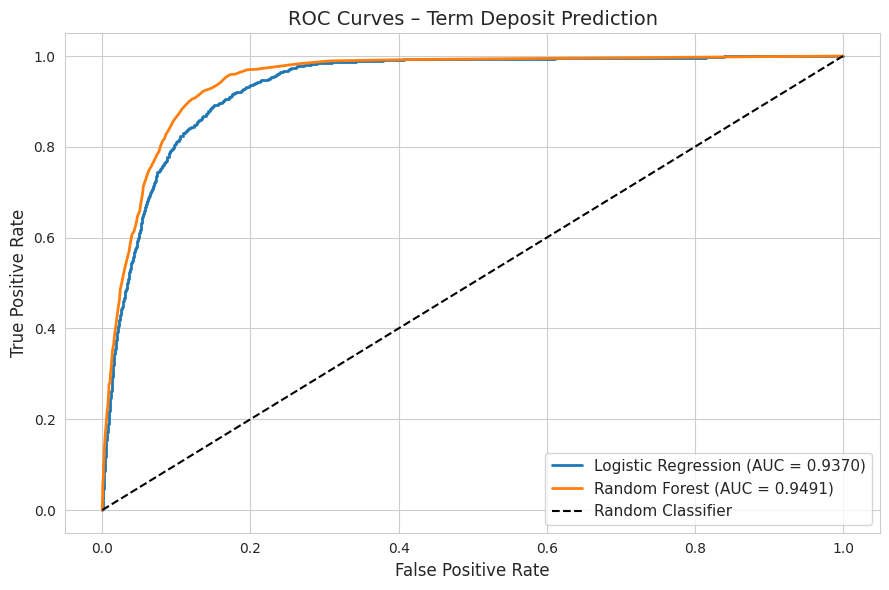

In [15]:
# ── ROC Curves ────────────────────────────────────────────────────────
plt.figure(figsize=(9, 6))

for name, y_prob in [('Logistic Regression', y_prob_lr), ('Random Forest', y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', lw=2)

plt.plot([0,1],[0,1],'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves – Term Deposit Prediction', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

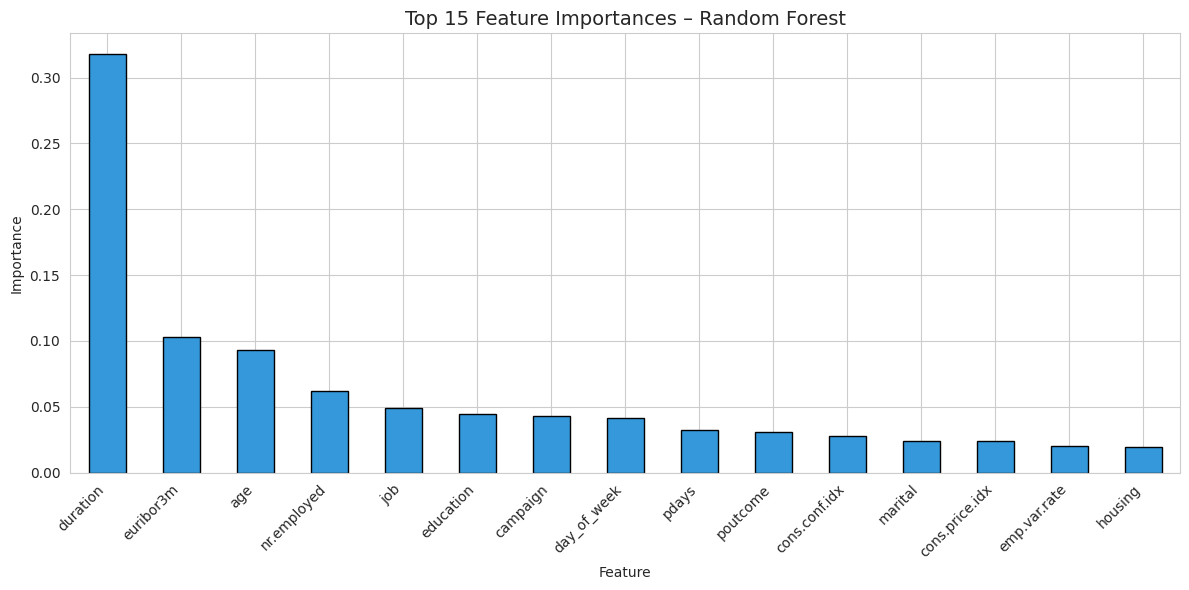


Top 10 Features:
duration       0.317703
euribor3m      0.103046
age            0.093309
nr.employed    0.061920
job            0.048895
education      0.044311
campaign       0.043099
day_of_week    0.041393
pdays          0.032722
poutcome       0.030670
dtype: float64


In [17]:
# ── Feature Importance (Random Forest) ───────────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
feat_imp.head(15).plot(kind='bar', color='#3498db', edgecolor='black')
plt.title('Top 15 Feature Importances – Random Forest', fontsize=14)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('\nTop 10 Features:')
print(feat_imp.head(10))

## 6. Explainable AI – SHAP Analysis

In [18]:
# SHAP Explainer for Random Forest
print('Computing SHAP values (this may take a minute)...')
explainer = shap.TreeExplainer(rf)

# Use a sample for speed
X_test_sample = X_test.iloc[:500]
shap_values = explainer.shap_values(X_test_sample)
print('SHAP values computed!')

Computing SHAP values (this may take a minute)...
SHAP values computed!


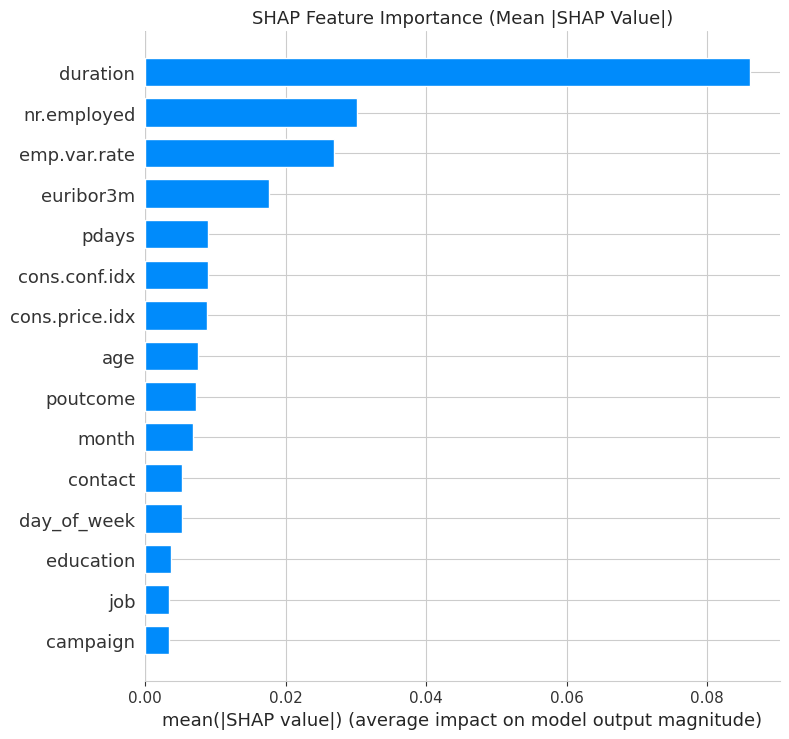

In [20]:
plt.figure()
shap.summary_plot(shap_values[:, :, 1], X_test_sample, plot_type='bar',
                  max_display=15, show=False)
plt.title('SHAP Feature Importance (Mean |SHAP Value|)', fontsize=13)
plt.tight_layout()
plt.show()

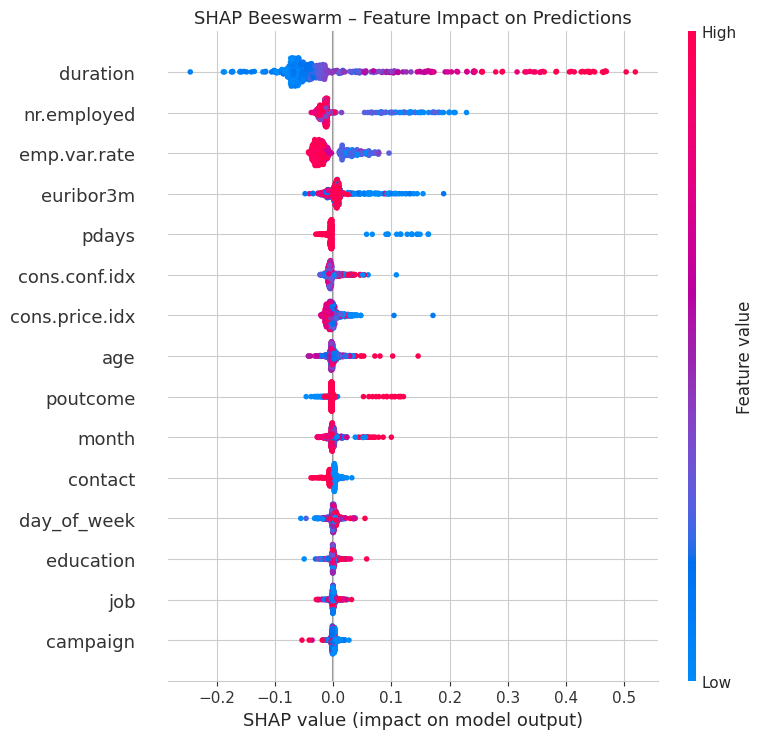

In [22]:
# SHAP Beeswarm Plot
shap.summary_plot(shap_values[:, :, 1], X_test_sample, max_display=15, show=False)
plt.title('SHAP Beeswarm – Feature Impact on Predictions', fontsize=13)
plt.tight_layout()
plt.show()


--- Prediction Explanation #1 ---
Actual: 0 | Predicted: 0


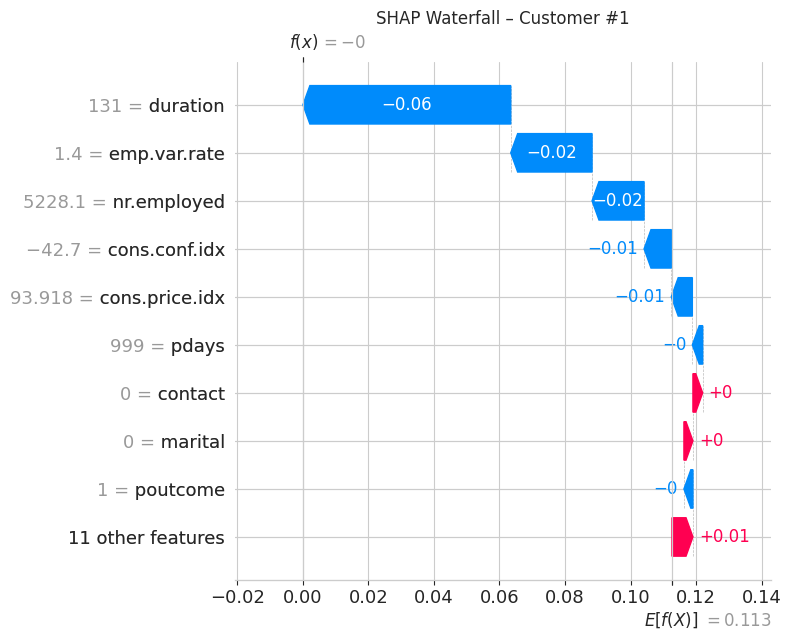


--- Prediction Explanation #2 ---
Actual: 0 | Predicted: 0


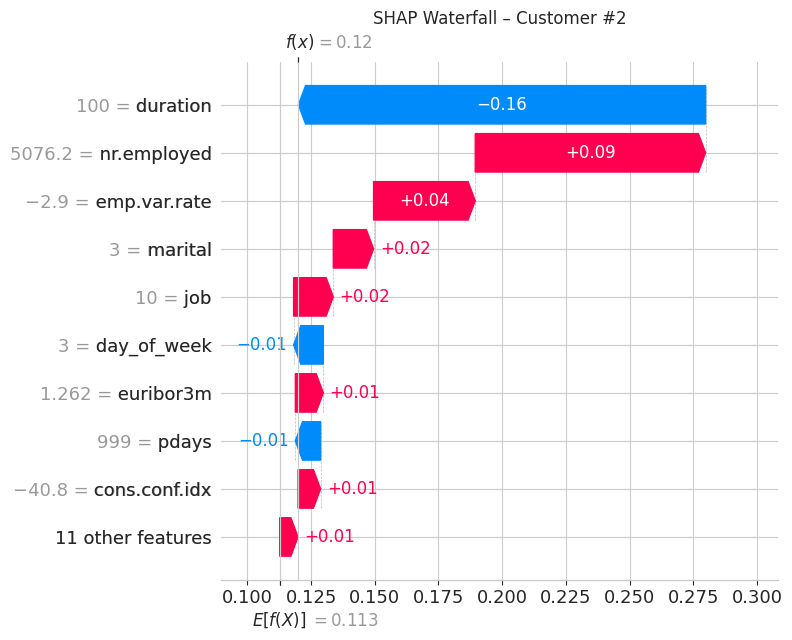


--- Prediction Explanation #3 ---
Actual: 0 | Predicted: 0


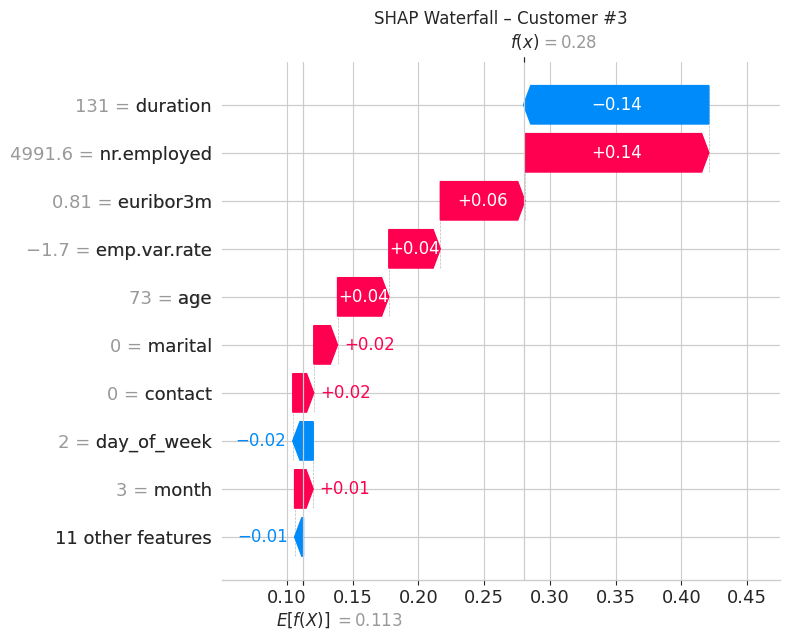


--- Prediction Explanation #4 ---
Actual: 0 | Predicted: 0


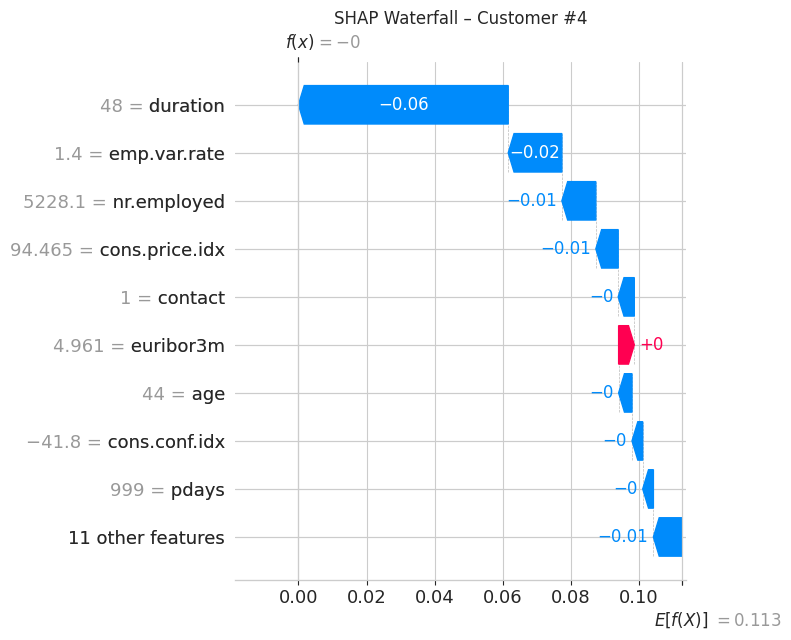


--- Prediction Explanation #5 ---
Actual: 0 | Predicted: 0


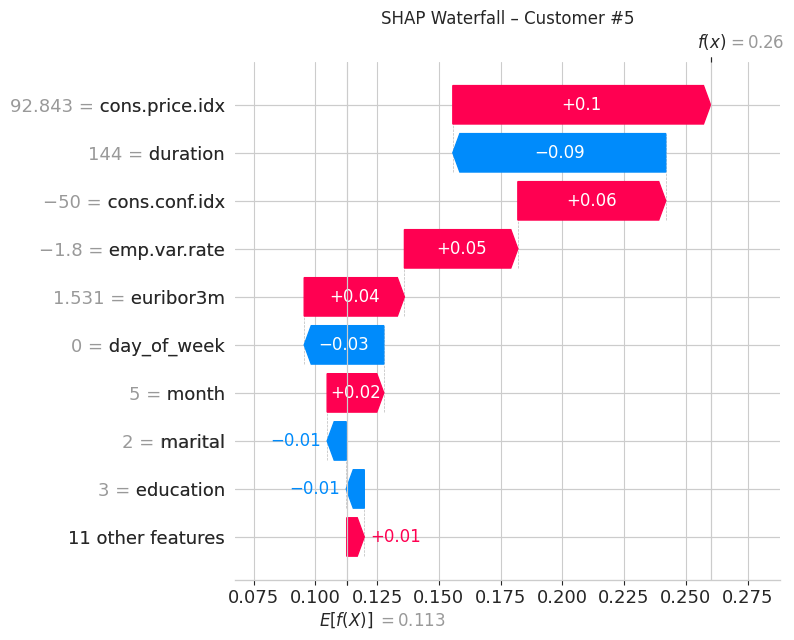

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score, ConfusionMatrixDisplay)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Data loading (assuming 'bank-additional-full.csv' is available)
df = pd.read_csv('bank-additional-full.csv', sep=';')

# Preprocessing (from cells wy5_I2DWMI18 and uvmNN5hmMI18)
df_model = df.copy()
df_model['y'] = (df_model['y'] == 'yes').astype(int)

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop('y', axis=1)
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=42, stratify=y)

# Random Forest Model Training (from cell 0I_ozbGiMI19)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# SHAP Explainer for Random Forest (from cell 7QxEDzZfMI1-)
X_test_sample = X_test.iloc[:500]

# SHAP Waterfall – 5 individual predictions explained
explainer = shap.TreeExplainer(rf)
shap_exp = explainer(X_test_sample)

for i in range(5):
    print(f'\n--- Prediction Explanation #{i+1} ---')
    print(f'Actual: {y_test.iloc[i]} | Predicted: {y_pred_rf[i]}')

    # Slice the shap_exp object directly to get the explanation for the current sample and 'yes' class
    explanation_for_current_sample_and_class_1 = shap_exp[i, :, 1]

    shap.plots.waterfall(explanation_for_current_sample_and_class_1, max_display=10, show=False)
    plt.title(f'SHAP Waterfall – Customer #{i+1}', fontsize=12)
    plt.tight_layout()
    plt.show()

## 7. Conclusion

## 7. Conclusion

### Model Performance Summary:

| Model | Accuracy | F1-Score | ROC-AUC |
|---|---|---|---|
| Logistic Regression | 91.39% | 0.5193 | 0.9370 |
| Random Forest | 92.04% | 0.6019 | 0.9491 |

### Key Findings:
- **Call Duration** is the single most important predictor — longer calls strongly correlate with subscriptions.
- **Month of contact** matters significantly — March, September, October, and December show higher subscription rates.
- **Job type** and **education level** influence subscription likelihood — retired and student customers subscribe at higher rates.
- **Previous campaign outcome** is a strong signal — customers who subscribed before are much more likely to subscribe again.

### SHAP Insights:
- SHAP analysis confirmed that duration, pdays, and previous contact outcomes drive most individual-level predictions.
- Customers with longer call durations consistently receive higher SHAP values pushing toward subscription.

### Business Recommendation:
The bank should prioritize calling customers who have previously subscribed and aim for longer, more engaged conversations. Campaigns in March and October yield the highest success rates. The Random Forest model should be deployed to score customers before campaigns to maximize ROI.